In [1]:
from show_img import show_img
import numpy as np
import cv2
from matplotlib import pyplot as plt

In [2]:
img = cv2.imread("bibizyana.jpg")
img_grayscale = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
# show_img(img)
# show_img(img_grayscale)

## 1. Гистограмма грейскейла

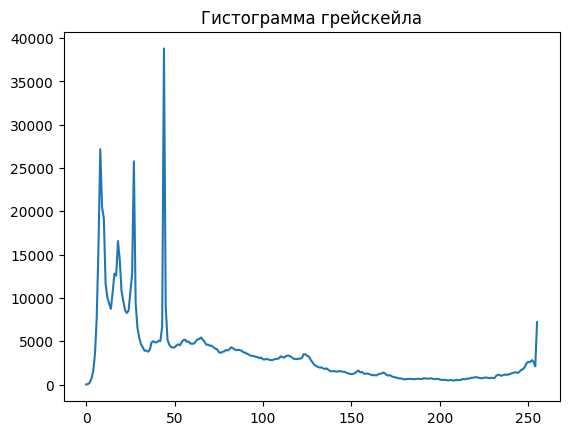

In [3]:
hist = cv2.calcHist([img_grayscale], [0], None, [256], [0, 256])
plt.plot(hist)
plt.title('Гистограмма грейскейла')
plt.show()

## 2. Гистограммы цветовых каналов

In [4]:
# подготовка фрагментов и масок для них
img_crop1 = img[420:700, 420:625]
show_img(img_crop1)
mask_monkey_head = np.zeros(img.shape[:2], np.uint8)
mask_monkey_head[420:700, 420:625] = 255

img_crop2 = img[35:400, 750:1030]
show_img(img_crop2)
mask_player = np.zeros(img.shape[:2], np.uint8)
mask_player[35:400, 750:1030] = 255

QFontDatabase: Cannot find font directory /home/oleg/study/image-processing/env/lib64/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/oleg/study/image-processing/env/lib64/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/oleg/study/image-processing/env/lib64/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFontDatabase: Cannot find font directory /home/oleg/study/image-processing/env/lib64/python3.13/site-packages/cv2/qt/fonts.
Note that Qt no longer ships fonts. Deploy some (from https://dejavu-fonts.github.io/ for example) or switch to fontconfig.
QFon

<function matplotlib.pyplot.show(close=None, block=None)>

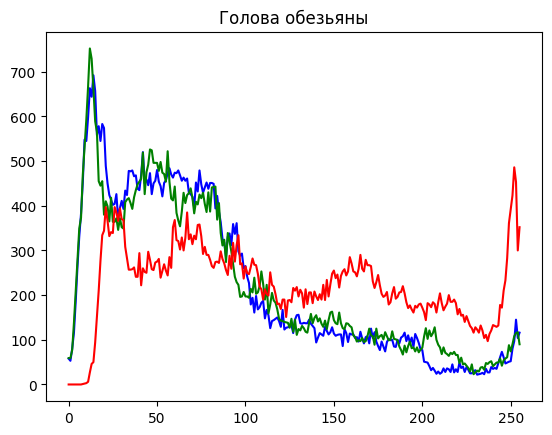

In [6]:
color = ('b', 'g', 'r')
for i, col in enumerate(color):
    hist1 = cv2.calcHist([img], [i], mask_monkey_head, [256], [0, 256])
    plt.plot(hist1, color = col)
plt.title("Голова обезьяны")
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

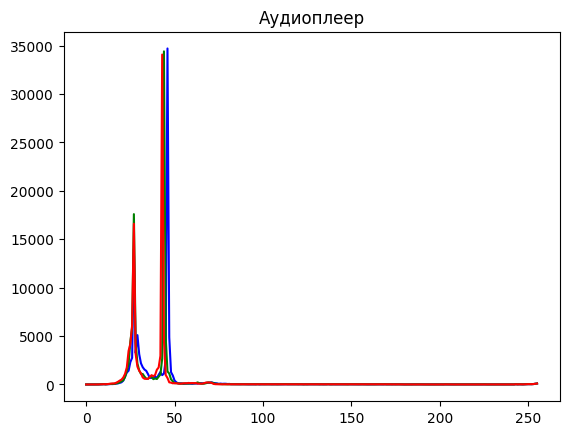

In [8]:
for i, col in enumerate(color):
    hist1 = cv2.calcHist([img], [i], mask_player, [256], [0, 256])
    plt.plot(hist1, color = col)
plt.title("Аудиоплеер")
plt.show

## 3. Контрастирование гистограммы

### Искусственное засветление

In [25]:
value = -50
img_bright = cv2.add(img, np.array([value, value, value]))

### Контрастирование гистаграммы цветного изображения

In [26]:
img_bright_yuv = cv2.cvtColor(img_bright, cv2.COLOR_BGR2YUV)
img_bright_yuv[:,:,0] = cv2.equalizeHist(img_bright_yuv[:,:,0])
img_bright_eql = cv2.cvtColor(img_bright_yuv, cv2.COLOR_YUV2BGR)
show_img(img_bright)
show_img(img_bright_eql)